In [1]:
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import math
import matplotlib.pyplot as plt

In [8]:
import torch

In [11]:
class MHSA(nn.Module):
  def __init__(self, d_model, h, dropout = 0.1):
    super().__init__()
    self.d_model = d_model
    self.h = h
    assert d_model % h == 0, "d_model is not divisible by h"
    self.d_k = d_model // h

    self.w_q = nn.Linear(d_model, d_model)
    self.w_k = nn.Linear(d_model, d_model)
    self.w_v = nn.Linear(d_model, d_model)
    self.w_o = nn.Linear(d_model, d_model)

    self.dropout = nn.Dropout(dropout) if dropout else None

  @staticmethod
  def attention(query, key, value, mask, dropout = None):
    d_k = query.shape[-1]
    attention_scores = (query @ key.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
      attention_scores.masked_fill_(mask == 0, -1e9)
    attention_scores = attention_scores.softmax(dim=-1)
    if dropout is not None:
      attention_scores = dropout(attention_scores)
    return (attention_scores @ value), attention_scores

  def forward(self, q, k, v, mask = None):
    query = self.w_q(q)
    key = self.w_k(k)
    value = self.w_v(v)

    query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1, 2)
    key = key.view(key.shape[0], key.shape[1], self.h, self.d_k).transpose(1, 2)
    value = value.view(value.shape[0], value.shape[1], self.h, self.d_k).transpose(1, 2)

    x, self.attention_scores = MHSA.attention(query, key, value, mask, self.dropout)
    x = x.transpose(1, 2).contiguous().view(x.shape[0], -1, self.h * self.d_k)
    return self.w_o(x)



In [12]:
class Encoder_Block(nn.Module):
  def __init__(self, d_model, num_heads, hidden_dim, dropout=0.1):
    super().__init__()
    self.mhsa = MHSA(d_model, h=num_heads, dropout=dropout)
    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, d_model),
            nn.Dropout(dropout)
        )


  def forward(self, x):
    x = x + self.mhsa(self.norm1(x), self.norm1(x), self.norm1(x), mask=None)
    x = x + self.mlp(self.norm2(x))
    return x



In [13]:
class ViT(nn.Module):
  def __init__(self, image_size=32, patch_size=4, d_model=128, num_heads=4, num_layers=2, num_classes=10):
    super().__init__()
    self.patch_embed = nn.Conv2d(3, d_model, kernel_size=patch_size, stride=patch_size) #(B, 128, 8, 8)
    num_patches = (image_size // patch_size) ** 2
    self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
    self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))

    self.blocks = nn.ModuleList([
        Encoder_Block(d_model, num_heads, hidden_dim=256)
        for _ in range(num_layers)
    ])

    self.norm = nn.LayerNorm(d_model)
    self.head = nn.Linear(d_model, num_classes)

  def forward(self, x):
    B = x.shape[0]
    x = self.patch_embed(x) #(B, 128, 8, 8)
    x = x.flatten(2).transpose(1, 2)     # (B, N, D) or (B, 64, 128)
    cls_tokens = self.cls_token.expand(B, -1, -1)

    x = torch.cat((cls_tokens, x), dim=1) #(B, 64, 128) → (B, 65, 128)
    x = x + self.pos_embed
    for block in self.blocks:
      x = block(x)
    x = self.norm(x)
    cls_out = x[:, 0] #(B, 128)
    return self.head(cls_out) #(B, 10)





In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ViT().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [17]:
from tqdm import tqdm

losses = []
for epoch in tqdm(range(25)):
    model.train()
    running_loss = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    losses.append(epoch_loss)

    print(f"epoch {epoch+1},loss: {epoch_loss:.4f}")

  4%|▍         | 1/25 [00:20<08:09, 20.40s/it]

epoch 1,loss: 1.6659


  8%|▊         | 2/25 [00:40<07:40, 20.03s/it]

epoch 2,loss: 1.4610


 12%|█▏        | 3/25 [01:01<07:32, 20.55s/it]

...

epoch 23,loss: 0.7381


 96%|█████████▌| 24/25 [08:19<00:20, 20.44s/it]

epoch 24,loss: 0.7214


100%|██████████| 25/25 [08:39<00:00, 20.77s/it]

epoch 25,loss: 0.7063


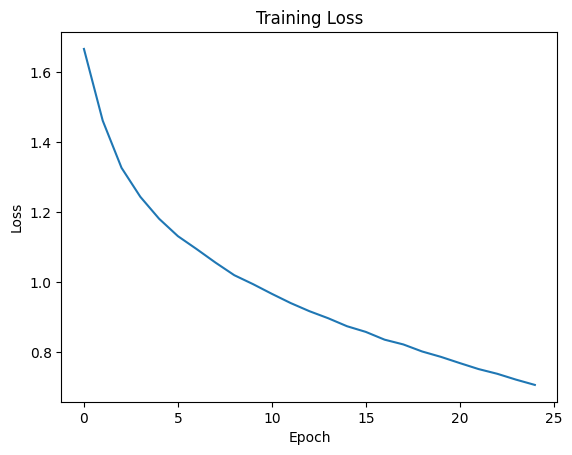

In [18]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [19]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"test Accuracy: {accuracy:.2f}%")

test Accuracy: 67.03%
